In [1]:
import numpy as np
import uproot as up

import matplotlib.pyplot as plt

In [16]:
#f2=up.open("../voxelstudy/Results_100k_17-3Voxel_Comparison.root")
#f2=up.open("../voxelstudy/Results_100k_17-3Voxel_Comparison_wires.root")
f2=up.open("../")
f2=up.open("../buildtest/Performance_Opticks_nowires.root")

In [17]:
Opticks=f2["OpticksHits"]
G4S=f2["Geant4Hits"]


In [18]:
print(Opticks.keys())
print(G4S.keys())

['evtID', 'hit_Id', 'SensorID', 'x', 'y', 'z', 't', 'wavelength', 'boundary']
['evtID', 'SensorID', 'SensorName', 'x', 'y', 'z', 't', 'wavelength', 'ProcessID']


In [19]:
def RatioCheck(Opticks, G4S):
    # Get event IDs
    opt_evt = Opticks["evtID"].array().to_numpy()
    g4_evt = G4S["evtID"].array().to_numpy()
    
    # Get max event ID
    maxEvent = int(max(opt_evt.max(), g4_evt.max())) + 1
    
    # Count photons per event using bincount (very fast)
    opt_counts = np.bincount(opt_evt, minlength=maxEvent)
    g4_counts = np.bincount(g4_evt, minlength=maxEvent)
    
    # Avoid division by zero
    mask = g4_counts > 0
    ratios = np.zeros(maxEvent)
    ratios[mask] = opt_counts[mask] / g4_counts[mask]
    
    # Create map for per-event ratio
    RatioMap = {evtid: ratios[evtid] for evtid in range(maxEvent) if g4_counts[evtid] > 0}
    
    print(f"Processed {maxEvent} events")
    print(f"Average ratio: {ratios[mask].mean():.4f}")
    
    return ratios, RatioMap 
    

In [20]:
k=RatioCheck(Opticks, G4S)

Processed 15 events
Average ratio: 1.0107


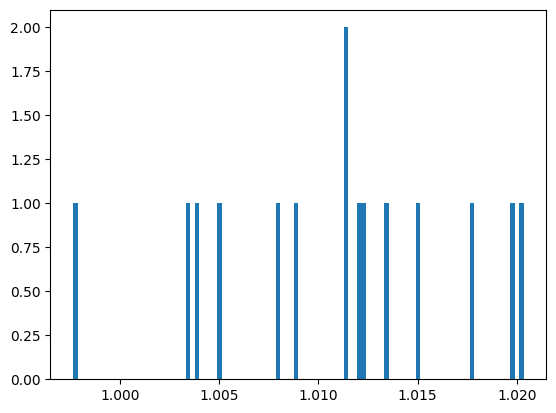

In [21]:
_=plt.hist(k[0],bins=100)

In [22]:
evtid=0
OpticksEventMask=Opticks["evtID"].array().to_numpy()==evtid
G4EventMask=G4S["evtID"].array().to_numpy()==evtid

In [23]:
ratio=len(Opticks["x"].array().to_numpy()[OpticksEventMask])/len(G4S["x"].array().to_numpy()[G4EventMask])
print(1-ratio)

-0.013476461458872269


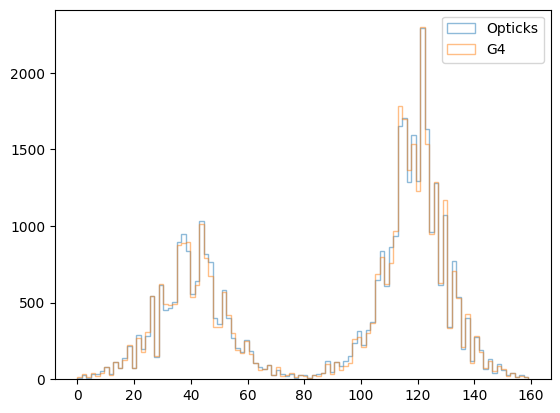

In [24]:

_=plt.hist(Opticks["SensorID"].array().to_numpy()[OpticksEventMask],bins=100,alpha=0.5,histtype="step",label="Opticks")
_=plt.hist(G4S["SensorID"].array().to_numpy()[G4EventMask],bins=100,alpha=0.5,histtype="step",label="G4")
plt.legend()
plt.show()

In [25]:
OX=Opticks["x"].array().to_numpy()

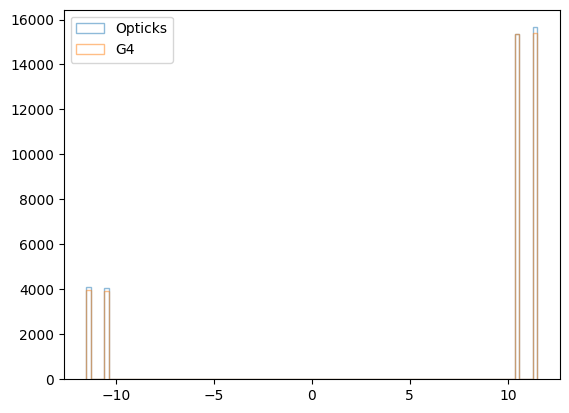

In [26]:
_=plt.hist(Opticks["x"].array().to_numpy()[OpticksEventMask],bins=100,alpha=0.5,histtype="step",label="Opticks")
_=plt.hist(G4S["x"].array().to_numpy()[G4EventMask],bins=100,alpha=0.5,histtype="step",label="G4")
plt.legend()
plt.show()

In [27]:
print(f"Opticks min {np.min(Opticks["SensorID"].array().to_numpy())} max {np.max(Opticks["SensorID"].array().to_numpy())}")
print(f"Opticks min {np.min(G4S["SensorID"].array().to_numpy())} max {np.max(G4S["SensorID"].array().to_numpy())}")

Opticks min 0 max 159
Opticks min 0 max 159


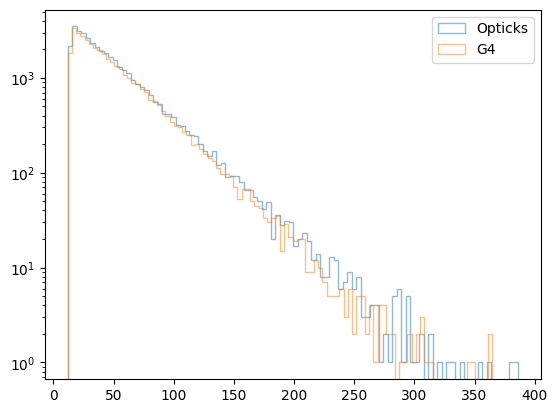

In [28]:
_=plt.hist(Opticks["t"].array().to_numpy()[OpticksEventMask],bins=100,alpha=0.5,histtype="step",label="Opticks")
_=plt.hist(G4S["t"].array().to_numpy()[G4EventMask],bins=100,alpha=0.5,histtype="step",label="G4")
plt.legend()
plt.semilogy()
plt.show()

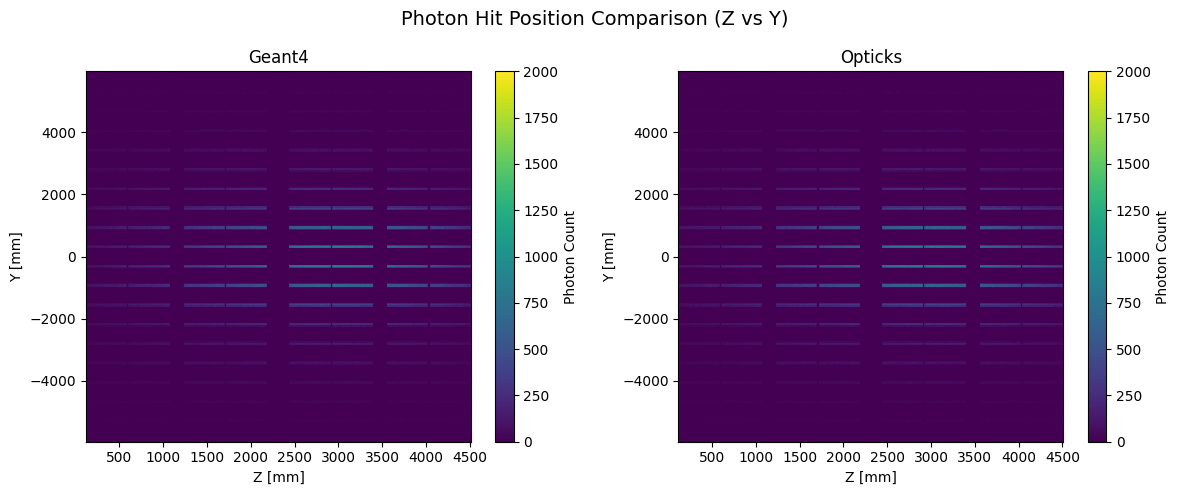

In [29]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
c=[0,2000]
bins=300
G4X=G4S["z"].array().to_numpy()
G4Y=G4S["y"].array().to_numpy()
OX=Opticks["z"].array().to_numpy()
OY=Opticks["y"].array().to_numpy()
xmin = min(G4X.min(), OX.min())
xmax = max(G4X.max(), OX.max())
xbins = np.linspace(xmin, xmax, bins)
ymin = min(G4Y.min(), OY.min())
ymax = max(G4Y.max(), OY.max())
ybins = np.linspace(ymin, ymax, bins)

# G4 histogram
h1 = axs[0].hist2d(
    G4X, 
    G4Y,
    bins=[xbins,ybins],
    vmin=c[0], 
    vmax=c[1],
    cmap='viridis'
)
axs[0].set_xlabel('Z [mm]')
axs[0].set_ylabel('Y [mm]')
axs[0].set_title('Geant4')
fig.colorbar(h1[3], ax=axs[0], label='Photon Count')

# Opticks histogram
h2 = axs[1].hist2d(
    OX, 
    OY,
    bins=[xbins,ybins],
    vmin=c[0], 
    vmax=c[1],
    cmap='viridis'
)
axs[1].set_xlabel('Z [mm]')
axs[1].set_ylabel('Y [mm]')
axs[1].set_title('Opticks')
fig.colorbar(h2[3], ax=axs[1], label='Photon Count')

fig.suptitle('Photon Hit Position Comparison (Z vs Y)', fontsize=14)
plt.tight_layout()
plt.show()